Sample Data:
    Soil_Nitrogen    Rainfall  Temperature  Water_Usage  Label
0      74.967142  632.408397    17.923146   420.039428      1
1      68.617357  561.491772    22.896773   427.715857      1
2      76.476885  532.307800    23.286427   345.598022      0
3      85.230299  661.167629    20.988614   418.580296      1
4      67.658466  703.099952    24.193571   423.445798      1
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6750 - loss: 0.7075
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6750 - loss: 0.7005
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6500 - loss: 0.6946
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6750 - loss: 0.6894
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6750 - loss: 0.6825 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7000 - loss: 0.6776
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6750 - loss: 0.6736
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.6670  
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6750 - loss: 0.6624
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6750 - loss: 0.6574 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6750 - loss: 0.6524
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 0.6477 
Epoch 13/

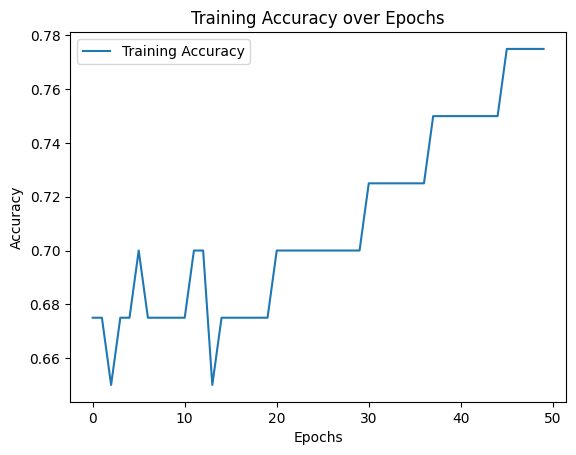

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#1.generate dataset
np.random.seed(42)
n_samples=50
data=pd.DataFrame({
    'Soil_Nitrogen':np.random.normal(70,10,n_samples),
    'Rainfall':np.random.normal(600,100,n_samples),
    'Temperature':np.random.normal(25,5,n_samples),
    'Water_Usage':np.random.normal(400,80,n_samples)
})

data['Label']=(
    (data['Soil_Nitrogen']>65)&
    (data['Rainfall']>550)&
    (data['Water_Usage']>350)
).astype(int)

print("Sample Data:\n",data.head())

#2.Split Features and labels
x=data.drop('Label',axis=1)
y=data['Label']

#3.train test split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

#4.Feature scaling
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#5.Build ANN model
model=Sequential()
model.add(Dense(8,activation='relu',input_dim=x_train.shape[1]))
model.add(Dense(6,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

#6.COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#7.train model
history=model.fit(
    x_train,y_train,
    epochs=50,
    batch_size=5,
    verbose=1
)

#8.PREDICTIONS
y_pred=model.predict(x_test)
y_pred=(y_pred>0.5).astype(int)

#9.evaluation metrics
print("\n---model evaluation---")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:",classification_report(y_test,y_pred))

#10.plot training performance
plt.figure()
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Epochs")
plt.legend()
plt.show()

